# Introduction to Progenetix

- access Progenetix data through a web API
- inspect the returned data structure
- convert the results into a pandas DataFrame
- perform a few simple summaries

## From website search to API access

Previously, we explored Progenetix through the website interface.

Here, we perform a similar type of query in Python. This makes the
workflow more reproducible and easier to extend for later analyses.

In [1]:
# Import the Python packages we need for this notebook.
# requests is used to send HTTP requests to the Progenetix API.
# pandas is used to organize the returned data as a table.

import requests
import pandas as pd

## Define the API query

We now define a simple API query.

In this example:
- we use the Progenetix Beacon biosamples endpoint
- we request a small number of results
- we use a filter term to limit the query

In [2]:
# Define the API endpoint.
# This URL points to the Progenetix Beacon biosamples service.

url = "https://progenetix.org/beacon/biosamples"

# Define the query parameters.
# "filters" is used to restrict the query.
# "limit" controls how many results we want to retrieve.

params = {
    "filters": "NCIT:C4872",
    "limit": 5
}

## Send the API request

We now send the request to the server and check whether it was successful.

In [3]:
# Send a GET request to the API using the URL and query parameters.
# The server will return a response object.

response = requests.get(url, params=params)

# Show the HTTP status code.
# A value of 200 usually means the request was successful.

response.status_code

200

## Convert the response to JSON

API responses are often returned in JSON format.
JSON is a structured text format that can be read into Python as a dictionary.

In [4]:
# Convert the API response to JSON format.
# The result is stored in the variable "data".

data = response.json()

# Show the top-level keys of the returned JSON object.
# This helps us understand the overall structure of the response.

data.keys()

dict_keys(['meta', 'response', 'responseSummary'])

## Inspect the response structure

The Progenetix API response contains several sections.
We now look inside the "response" part to find the actual results.

In [5]:
# Look at the keys inside the "response" section.
# This helps us locate where the returned sample data is stored.

data["response"].keys()

dict_keys(['resultSets'])

## Extract the results

The sample records are stored inside the "results" field.
We extract them into a separate variable for easier use.

In [6]:
# Extract the first result set from the API response.
# This object contains metadata and the actual list of returned records.

result_set = data["response"]["resultSets"][0]

# Show the keys of this result set.
result_set.keys()

dict_keys(['exists', 'id', 'info', 'responseEntityId', 'results', 'resultsCount', 'resultsHandovers', 'setType'])

In [7]:
# Extract the list of biosample records from the result set.
# Each element in "results" corresponds to one returned biosample.

results = result_set["results"]

# Show how many biosample records are included in this result set.
len(results)

5

## Inspect one result

Before converting the results into a table, it is useful to look at
one example record directly.

In [8]:
# Display the first biosample record.
# This helps us understand the structure of one sample entry.

results[0]

{'biosampleStatus': {'id': 'EFO:0010941', 'label': 'metastasis sample'},
 'cohorts': [{'id': 'pgx:cohort-GENIE-MSK',
   'label': 'GENIE samples, Memorial Sloan Kettering Cancer Center'},
  {'id': 'pgx:cohort-GENIE', 'label': 'AACR GENIE project samples'}],
 'collectionMoment': 'P58Y',
 'collectionMomentDays': 21184,
 'externalReferences': [],
 'geoLocation': {'geometry': {'coordinates': [-74.00857, 40.70789],
   'type': 'Point'},
  'properties': {'ISO3166alpha2': 'US',
   'ISO3166alpha3': 'USA',
   'city': 'Financial District',
   'continent': 'North America',
   'country': 'United States',
   'id': 'financialdistrict::unitedstates::-74.00857::40.70789',
   'label': 'Financial District, United States'},
  'type': 'Feature'},
 'histologicalDiagnosis': {'id': 'NCIT:C9245',
  'label': 'Invasive Breast Carcinoma'},
 'icdoMorphology': {'id': 'pgx:icdom-85003',
  'label': 'Infiltrating duct carcinoma, NOS'},
 'icdoTopography': {'id': 'pgx:icdot-C50.9', 'label': 'Breast, NOS'},
 'id': 'pgxbs-

## Convert the results into a pandas DataFrame

The returned results are still in nested JSON format.
Using pandas, we can convert them into a table for easier inspection.

In [9]:
# Convert the list of biosample records into a pandas DataFrame.
# pd.json_normalize() flattens nested JSON fields into columns.

df = pd.json_normalize(results)

# Display the first few rows of the DataFrame.
df.head()

,cohorts,collectionMoment,collectionMomentDays,externalReferences,id,individualId,name,notes,updated,biosampleStatus.id,...,sampleOriginType.label,analysisInfo.experimentId,analysisInfo.platformId,analysisInfo.seriesId,pathologicalStage.id,pathologicalStage.label,provenance.populations,pathologicalTnmFindings,tumorGrade.id,tumorGrade.label
0,"[{'id': 'pgx:cohort-GENIE-MSK', 'label': 'GENI...",P58Y,21184.0,[],pgxbs-m84dickj,pgxind-m84dd9j0,GENIE-MSK-P-0095198-T03-IM7,Invasive Breast Carcinoma [metastasis],2025-06-12T13:46:07.226981,EFO:0010941,...,specimen from organism,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[{'id': 'pgx:cohort-arraymap', 'label': 'array...",NaN,NaN,"[{'description': 'Fles R, Hoogendoorn WE et al...",pgxbs-kftvizz1,pgxind-kftx4rye,GSM418121,breast carcinoma,2025-07-11T16:55:25.688821,EFO:0009656,...,specimen from organism,geo:GSM418121,geo:GPL4560,geo:GSE16680,NCIT:C92207,Stage Unknown,NaN,NaN,NaN,NaN
2,"[{'id': 'pgx:cohort-arraymap', 'label': 'array...",NaN,NaN,[{'description': 'Vincent-Salomon A et al. (20...,pgxbs-kftvja5v,pgxind-kftx54rs,GSM1169823,breast carcinoma,2025-07-11T16:55:25.814634,EFO:0009656,...,specimen from organism,geo:GSM1169823,geo:GPL6801,geo:GSE48064,NCIT:C92207,Stage Unknown,"[{'confidence': 0.0, 'description': 'SNP2pop 1...",NaN,NaN,NaN
3,"[{'id': 'pgx:cohort-2021progenetix', 'label': ...",P35Y,12783.0,"[{'description': 'Weber-Mangal S, Sinn HP et a...",pgxbs-kftvh5fy,pgxind-kftx30l1,BrCaYW-62,invasive ductal carcinoma of the breast [grade...,2025-07-11T16:55:24.342283,EFO:0009656,...,specimen from organism,NaN,NaN,NaN,NCIT:C27971,Stage IV,NaN,"[{'id': 'NCIT:C48732', 'label': 'T4 Stage Find...",NCIT:C28079,Grade 3
4,"[{'id': 'pgx:cohort-arraymap', 'label': 'array...",NaN,NaN,"[{'description': 'Jiang YZ, Ma D, Suo C et al....",pgxbs-kftvkikx,pgxind-kftx6ma3,GSM3331625,Triple negative breast carcinoma,2020-09-10 17:46:45.439000,EFO:0009656,...,specimen from organism,geo:GSM3331625,geo:GPL21558,geo:GSE118527,NCIT:C92207,Stage Unknown,NaN,NaN,NaN,NaN


## Inspect the DataFrame

Now that the results are stored as a table, we can inspect:
- the number of rows and columns
- the available column names

In [10]:
# Show the shape of the DataFrame.
# The output gives the number of rows and columns.

df.shape

(5, 43)

In [11]:
# Show the column names of the DataFrame.
# This helps us understand what variables are available.

df.columns

Index(['cohorts', 'collectionMoment', 'collectionMomentDays',
       'externalReferences', 'id', 'individualId', 'name', 'notes', 'updated',
       'biosampleStatus.id', 'biosampleStatus.label',
       'geoLocation.geometry.coordinates', 'geoLocation.geometry.type',
       'geoLocation.properties.ISO3166alpha2',
       'geoLocation.properties.ISO3166alpha3', 'geoLocation.properties.city',
       'geoLocation.properties.continent', 'geoLocation.properties.country',
       'geoLocation.properties.id', 'geoLocation.properties.label',
       'geoLocation.type', 'histologicalDiagnosis.id',
       'histologicalDiagnosis.label', 'icdoMorphology.id',
       'icdoMorphology.label', 'icdoTopography.id', 'icdoTopography.label',
       'individualInfo.ageDays', 'individualInfo.sex.id',
       'individualInfo.sex.label', 'sampleOriginDetail.id',
       'sampleOriginDetail.label', 'sampleOriginType.id',
       'sampleOriginType.label', 'analysisInfo.experimentId',
       'analysisInfo.platformId', '

In this example, the query matched many biosamples in Progenetix.

However, because we set `limit = 5`, the API returned only the first
five biosample records.

This is useful for learning and testing the workflow before requesting
larger amounts of data.

In [12]:
# Show the total number of matching biosamples reported by the API.
data["response"]["resultSets"][0]["resultsCount"]

21886

## Understanding the data hierarchy

Each row in this table represents one **biosample**.

A simplified hierarchy is:

- **individual**: the patient or individual
- **biosample**: one biological sample from that individual
- **analysis**: an experiment performed on that sample

In the current table, we can directly see:
- `individualId` for the individual level
- `id` and `name` for the biosample level
- several annotation fields describing the sample

In [13]:
# Select a few columns that illustrate the hierarchy.
# Each row is one biosample.
# The selected columns show:
# - individual level
# - biosample level
# - sample annotation level

df[[
    "individualId",
    "id",
    "name",
    "biosampleStatus.label",
    "sampleOriginDetail.label",
    "sampleOriginType.label"
]].head()

,individualId,id,name,biosampleStatus.label,sampleOriginDetail.label,sampleOriginType.label
0,pgxind-m84dd9j0,pgxbs-m84dickj,GENIE-MSK-P-0095198-T03-IM7,metastasis sample,breast,specimen from organism
1,pgxind-kftx4rye,pgxbs-kftvizz1,GSM418121,neoplastic sample,breast,specimen from organism
2,pgxind-kftx54rs,pgxbs-kftvja5v,GSM1169823,neoplastic sample,breast,specimen from organism
3,pgxind-kftx30l1,pgxbs-kftvh5fy,BrCaYW-62,neoplastic sample,breast,specimen from organism
4,pgxind-kftx6ma3,pgxbs-kftvkikx,GSM3331625,neoplastic sample,breast,specimen from organism


## Important classification fields

Several columns describe how a biosample is classified.

These fields help answer different questions:

- **histologicalDiagnosis**: what is the overall tumor diagnosis?
- **icdoMorphology**: what is the tumor morphology or histological type?
- **icdoTopography**: where in the body does the tumor occur?
- **pathologicalStage**: what is the tumor stage?
- **sampleOriginDetail / sampleOriginType**: from what tissue or specimen type was the sample obtained?

Together, these fields help structure cancer samples in a standardized way.

In [14]:
# Display a subset of columns related to classification and sample annotation.
# These columns describe diagnosis, morphology, anatomical site, stage,
# and sample origin.

df[[
    "name",
    "histologicalDiagnosis.label",
    "icdoMorphology.label",
    "icdoTopography.label",
    "pathologicalStage.label",
    "sampleOriginDetail.label",
    "sampleOriginType.label"
]].head()

,name,histologicalDiagnosis.label,icdoMorphology.label,icdoTopography.label,pathologicalStage.label,sampleOriginDetail.label,sampleOriginType.label
0,GENIE-MSK-P-0095198-T03-IM7,Invasive Breast Carcinoma,"Infiltrating duct carcinoma, NOS","Breast, NOS",NaN,breast,specimen from organism
1,GSM418121,Breast Ductal Carcinoma,"Infiltrating duct carcinoma, NOS","Breast, NOS",Stage Unknown,breast,specimen from organism
2,GSM1169823,Breast Ductal Carcinoma,"Infiltrating duct carcinoma, NOS","Breast, NOS",Stage Unknown,breast,specimen from organism
3,BrCaYW-62,Breast Ductal Carcinoma,"Infiltrating duct carcinoma, NOS","Breast, NOS",Stage IV,breast,specimen from organism
4,GSM3331625,Triple-Negative Breast Carcinoma,"Carcinoma, NOS","Breast, NOS",Stage Unknown,breast,specimen from organism


## Bulk download: from sample annotations to CNV frequency data

So far, we have explored a small number of biosamples through the API.

For larger-scale exploration, Progenetix also provides bulk download
services. In this part of the notebook, we will:

- download sample annotations from Progenetix
- explore how cancer samples are described
- filter the metadata to keep primary tumor samples
- compare diagnostic annotations across downloaded groups
- explain the difference between raw CNV segments and precomputed CNV frequencies
- download and export CNV frequency tables for later use



## Coding systems used in Progenetix

Progenetix uses standardized diagnostic coding systems, especially
ICD-O and NCIt.

we use query codes only to download sample groups.
For interpretation, we rely on the annotation columns already present
in the downloaded tables, such as:

- `histological_diagnosis_label`
- `icdo_morphology_label`
- `icdo_topography_label`

This helps us keep the biological interpretation separate from the
technical query used for download.

## Part 1. Download sample metadata

We first download sample annotation tables for two selected cancer
queries.

These tables contain sample-level metadata, with one row per biosample.

In [15]:
# Import the packages needed for downloading and processing tabular data.

import requests
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

In [16]:
# Define the sampletable URLs for three selected cancer queries.
# limit=0 means that all matching samples are requested.

sampletable_urls = {
    "infiltrating_duct_carcinoma_icdom": "https://progenetix.org/services/sampletable/?filters=pgx:icdom-85003&limit=0",
    "squamous_cell_carcinoma_icdom": "https://progenetix.org/services/sampletable/?filters=pgx:icdom-80703&limit=0"
}

## Download the sample tables

Each downloaded table corresponds to one query group.

To keep track of which query produced which rows, we add a technical
column called `source_query`.

This is not a biological cancer label. It only records the origin of
the downloaded table.

In [17]:
# Download sample tables and store them in a dictionary.

sampletables = {}

for source_query, url in sampletable_urls.items():
    print(f"Downloading sample table for {source_query}")
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    df_tmp = pd.read_csv(StringIO(response.text), sep="\t")
    df_tmp["source_query"] = source_query
    sampletables[source_query] = df_tmp

In [18]:
# Show the size of each downloaded sample table.

for source_query, df_tmp in sampletables.items():
    print(source_query, df_tmp.shape)

infiltrating_duct_carcinoma_icdom (18647, 43)
squamous_cell_carcinoma_icdom (9721, 43)


## Explore one sample table

We start with one example table and inspect its structure.

In [19]:
# Use the breast ductal carcinoma query as an example.

sampletable_df = sampletables["infiltrating_duct_carcinoma_icdom"].copy()

sampletable_df.head()

,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,biosample_status_id,biosample_status_label,...,geoprov_city,geoprov_country,geoprov_iso_alpha3,geoprov_long_lat,followup_days,sex_id,sex_label,group_id,group_label,source_query
0,pgxbs-kftvkrqh,pgxind-kftx6xcu,BREAST_MSK_2018-P_0014577_T01_IM6,Breast Invasive Ductal Carcinoma,NCIT:C9245,Invasive Breast Carcinoma,NCIT:C92207,Stage Unknown,EFO:0009656,neoplastic sample,...,Financial District,United States,USA,-74.00857::40.70789,NaN,NaN,NaN,NaN,NaN,infiltrating_duct_carcinoma_icdom
1,pgxbs-kftviiv0,pgxind-kftx47kk,GSM378125,breast carcinoma,NCIT:C4017,Breast Ductal Carcinoma,NCIT:C92207,Stage Unknown,EFO:0009656,neoplastic sample,...,St. Louis,United States,USA,-90.19789::38.62727,NaN,NaN,NaN,NaN,NaN,infiltrating_duct_carcinoma_icdom
2,pgxbs-m84d4kzc,pgxind-m84d2ivn,GENIE-MSK-P-0045879-T01-IM6,Invasive Breast Carcinoma [metastasis],NCIT:C9245,Invasive Breast Carcinoma,NaN,NaN,EFO:0010941,metastasis sample,...,Financial District,United States,USA,-74.00857::40.70789,NaN,NaN,NaN,NaN,NaN,infiltrating_duct_carcinoma_icdom
3,pgxbs-kftvhdns,pgxind-kftx3au6,BC-FN-05,Invasive DCIS,NCIT:C4017,Breast Ductal Carcinoma,NCIT:C92207,Stage Unknown,EFO:0009656,neoplastic sample,...,New Haven,United States,USA,-72.92816::41.30815,NaN,NaN,NaN,NaN,NaN,infiltrating_duct_carcinoma_icdom
4,pgxbs-kftvhqiu,pgxind-kftx3orp,92b16015-e552-48e3-a095-0197b99b52a8,Primary Tumor,NCIT:C4017,Ductal Breast Carcinoma,NCIT:C27982,Stage IIIC,EFO:0009656,neoplastic sample,...,Chapel Hill,United States,USA,-79.05584::35.9132,NaN,NaN,NaN,NaN,NaN,infiltrating_duct_carcinoma_icdom


## Key metadata columns

Some important columns in the sample table are:

- `biosample_id`: sample identifier
- `individual_id`: individual identifier
- `biosample_name`: sample name
- `histological_diagnosis_label`: diagnosis label
- `icdo_morphology_label`: ICD-O morphology
- `icdo_topography_label`: ICD-O topography
- `biosample_status_label`: sample status
- `sample_origin_type_label`: type of sample origin
- `sampled_tissue_label`: sampled tissue

In [20]:
# Show the column names of the sample table.

sampletable_df.columns

Index(['biosample_id', 'individual_id', 'biosample_name', 'notes',
       'histological_diagnosis_id', 'histological_diagnosis_label',
       'pathological_stage_id', 'pathological_stage_label',
       'biosample_status_id', 'biosample_status_label',
       'sample_origin_type_id', 'sample_origin_type_label',
       'sampled_tissue_id', 'sampled_tissue_label', 'tnm', 'tumor_grade_id',
       'tumor_grade_label', 'age_iso', 'age_days', 'icdo_morphology_id',
       'icdo_morphology_label', 'icdo_topography_id', 'icdo_topography_label',
       'pubmed_id', 'pubmed_label', 'cellosaurus_id', 'cellosaurus_label',
       'cbioportal_id', 'cbioportal_label', 'tcgaproject_id',
       'tcgaproject_label', 'cohorts', 'geoprov_id', 'geoprov_city',
       'geoprov_country', 'geoprov_iso_alpha3', 'geoprov_long_lat',
       'followup_days', 'sex_id', 'sex_label', 'group_id', 'group_label',
       'source_query'],
      dtype='str')

In [21]:
# Display a subset of important columns.

sampletable_df[[
    "biosample_id",
    "individual_id",
    "biosample_name",
    "notes",
    "histological_diagnosis_label",
    "icdo_morphology_label",
    "icdo_topography_label",
    "biosample_status_label",
    "sample_origin_type_label",
    "sampled_tissue_label",
    "source_query"
]].head()

,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_label,icdo_morphology_label,icdo_topography_label,biosample_status_label,sample_origin_type_label,sampled_tissue_label,source_query
0,pgxbs-kftvkrqh,pgxind-kftx6xcu,BREAST_MSK_2018-P_0014577_T01_IM6,Breast Invasive Ductal Carcinoma,Invasive Breast Carcinoma,"Infiltrating duct carcinoma, NOS","Breast, NOS",neoplastic sample,specimen from organism,breast,infiltrating_duct_carcinoma_icdom
1,pgxbs-kftviiv0,pgxind-kftx47kk,GSM378125,breast carcinoma,Breast Ductal Carcinoma,"Infiltrating duct carcinoma, NOS","Breast, NOS",neoplastic sample,specimen from organism,breast,infiltrating_duct_carcinoma_icdom
2,pgxbs-m84d4kzc,pgxind-m84d2ivn,GENIE-MSK-P-0045879-T01-IM6,Invasive Breast Carcinoma [metastasis],Invasive Breast Carcinoma,"Infiltrating duct carcinoma, NOS","Breast, NOS",metastasis sample,NaN,breast,infiltrating_duct_carcinoma_icdom
3,pgxbs-kftvhdns,pgxind-kftx3au6,BC-FN-05,Invasive DCIS,Breast Ductal Carcinoma,"Infiltrating duct carcinoma, NOS","Breast, NOS",neoplastic sample,specimen from organism,breast,infiltrating_duct_carcinoma_icdom
4,pgxbs-kftvhqiu,pgxind-kftx3orp,92b16015-e552-48e3-a095-0197b99b52a8,Primary Tumor,Ductal Breast Carcinoma,"Infiltrating duct carcinoma, NOS","Breast, NOS",neoplastic sample,specimen from organism,breast,infiltrating_duct_carcinoma_icdom


## Missing values and data completeness

Real biological datasets often contain missing values.

We now inspect which columns are relatively complete and which columns
contain many missing entries.

In [22]:
# Count missing values in each column.

sampletable_df.isna().sum().sort_values(ascending=False)

group_label                     18647
group_id                        18647
sex_label                       18647
sex_id                          18647
followup_days                   18647
age_days                        18647
tumor_grade_label               18539
tumor_grade_id                  18539
cellosaurus_label               17774
cellosaurus_id                  17774
tcgaproject_id                  17713
tcgaproject_label               17713
tnm                             16514
cbioportal_label                16507
cbioportal_id                   15914
age_iso                          7806
pubmed_id                        6881
pubmed_label                     6881
sample_origin_type_label         5689
sample_origin_type_id            5689
pathological_stage_label         5689
pathological_stage_id            5689
geoprov_country                     0
geoprov_iso_alpha3                  0
geoprov_city                        0
geoprov_id                          0
cohorts     

## Explore biosample status

Before filtering, we inspect the sample status categories present in the
downloaded table.

In [23]:
# Count biosample status values.

sampletable_df["biosample_status_label"].value_counts(dropna=False)

biosample_status_label
neoplastic sample          11534
metastasis sample           3453
primary tumor sample        2732
cancer cell line sample      873
recurrent tumor sample        55
Name: count, dtype: int64

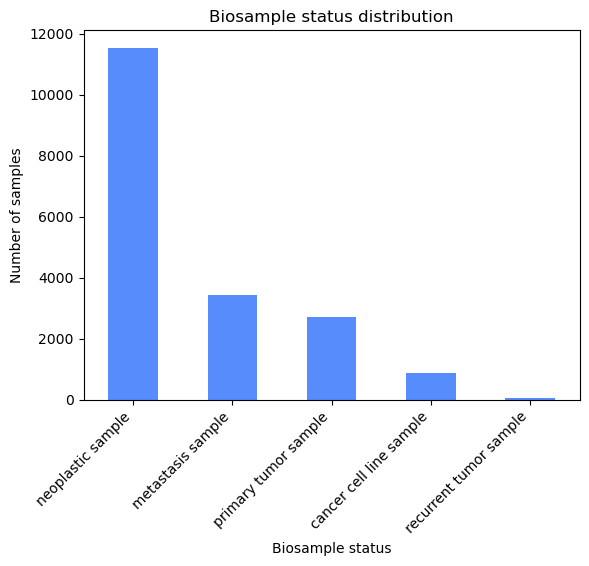

In [24]:
# Plot the biosample status distribution.

sampletable_df["biosample_status_label"].value_counts().plot(kind="bar")
plt.title("Biosample status distribution")
plt.xlabel("Biosample status")
plt.ylabel("Number of samples")
plt.xticks(rotation=45, ha="right")
plt.show()

## Filter to primary tumor samples

For downstream comparison, we restrict the metadata tables to
`primary tumor sample`.

This creates a cleaner and biologically more consistent subset.

In [25]:
# Keep only primary tumor samples in each downloaded table.

filtered_tables = {}

for source_query, df_tmp in sampletables.items():
    filtered_df = df_tmp[
        df_tmp["biosample_status_label"] == "primary tumor sample"
    ].copy()
    filtered_tables[source_query] = filtered_df

In [26]:
# Compare sample counts before and after filtering.

for source_query in sampletables.keys():
    before_n = sampletables[source_query].shape[0]
    after_n = filtered_tables[source_query].shape[0]
    print(f"{source_query}: before = {before_n}, after = {after_n}")

infiltrating_duct_carcinoma_icdom: before = 18647, after = 2732
squamous_cell_carcinoma_icdom: before = 9721, after = 1796


## Combine the filtered metadata tables

We now concatenate the filtered tables into one combined sample metadata
dataset.

The original biological labels remain in the metadata columns.
The technical `source_query` column is only used to record where each
row came from.

In [27]:
# Concatenate the filtered sample tables.

combined_sampletable_df = pd.concat(
    [filtered_tables[source_query] for source_query in filtered_tables],
    ignore_index=True
)

combined_sampletable_df.shape

(4528, 43)

In [28]:
# Display the first rows of the combined filtered metadata table.

combined_sampletable_df.head()

,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,biosample_status_id,biosample_status_label,...,geoprov_city,geoprov_country,geoprov_iso_alpha3,geoprov_long_lat,followup_days,sex_id,sex_label,group_id,group_label,source_query
0,pgxbs-m84cylrd,pgxind-m84cy585,GENIE-MSK-P-0017631-T01-IM5,Breast Invasive Ductal Carcinoma,NCIT:C4194,Invasive Breast Carcinoma of No Special Type,NaN,NaN,EFO:0010942,primary tumor sample,...,Financial District,United States,USA,-74.00857::40.70789,NaN,NaN,NaN,NaN,NaN,infiltrating_duct_carcinoma_icdom
1,pgxbs-m84d5i3b,pgxind-m84d334b,GENIE-MSK-P-0050519-T01-IM6,Invasive Breast Carcinoma,NCIT:C9245,Invasive Breast Carcinoma,NaN,NaN,EFO:0010942,primary tumor sample,...,Financial District,United States,USA,-74.00857::40.70789,NaN,NaN,NaN,NaN,NaN,infiltrating_duct_carcinoma_icdom
2,pgxbs-m84cyla5,pgxind-m84cy4un,GENIE-MSK-P-0017478-T02-IM6,Breast Invasive Ductal Carcinoma,NCIT:C4194,Invasive Breast Carcinoma of No Special Type,NaN,NaN,EFO:0010942,primary tumor sample,...,Financial District,United States,USA,-74.00857::40.70789,NaN,NaN,NaN,NaN,NaN,infiltrating_duct_carcinoma_icdom
3,pgxbs-m84d7rsy,pgxind-m84d4ppc,GENIE-MSK-P-0058659-T01-IM7,Breast Invasive Ductal Carcinoma,NCIT:C4194,Invasive Breast Carcinoma of No Special Type,NaN,NaN,EFO:0010942,primary tumor sample,...,Financial District,United States,USA,-74.00857::40.70789,NaN,NaN,NaN,NaN,NaN,infiltrating_duct_carcinoma_icdom
4,pgxbs-m84cz1x8,pgxind-m3io23y2,GENIE-MSK-P-0020593-T01-IM6,Breast Invasive Ductal Carcinoma,NCIT:C4194,Invasive Breast Carcinoma of No Special Type,NaN,NaN,EFO:0010942,primary tumor sample,...,Financial District,United States,USA,-74.00857::40.70789,NaN,NaN,NaN,NaN,NaN,infiltrating_duct_carcinoma_icdom


## Understanding labels in the metadata table

The metadata table contains several structured labels.

These labels describe different aspects of the same sample:
- diagnosis
- morphology
- anatomical site

They are related, but they are not identical.

In [29]:
# Count histological diagnosis labels.

combined_sampletable_df["histological_diagnosis_label"].value_counts().head(20)

histological_diagnosis_label
Invasive Breast Carcinoma of No Special Type                2203
Lung Squamous Cell Carcinoma                                 793
Invasive Breast Carcinoma                                    528
Esophageal Squamous Cell Carcinoma                           138
Head and Neck Squamous Cell Carcinoma                        131
Cervical Squamous Cell Carcinoma                             130
Oral Cavity Squamous Cell Carcinoma                          123
Anal Squamous Cell Carcinoma                                 117
Skin Squamous Cell Carcinoma                                  72
Vaginal Squamous Cell Carcinoma, Not Otherwise Specified      58
Oropharyngeal Squamous Cell Carcinoma                         52
Squamous Cell Carcinoma                                       51
Esophageal Poorly Differentiated Squamous Cell Carcinoma      35
Bladder Squamous Cell Carcinoma                               25
Laryngeal Squamous Cell Carcinoma                            

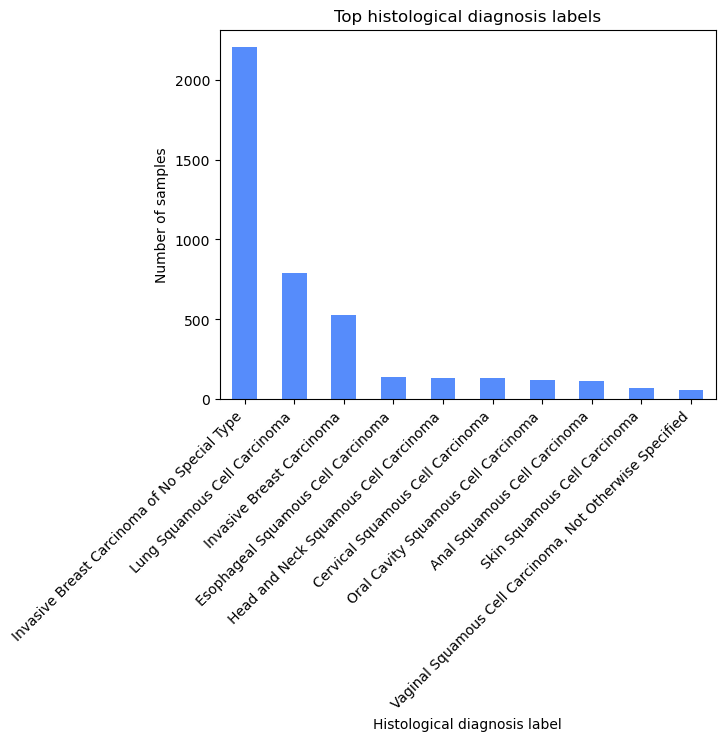

In [30]:
# Plot the top 10 histological diagnosis labels.

combined_sampletable_df["histological_diagnosis_label"].value_counts().head(10).plot(kind="bar")
plt.title("Top histological diagnosis labels")
plt.xlabel("Histological diagnosis label")
plt.ylabel("Number of samples")
plt.xticks(rotation=45, ha="right")
plt.show()

In [31]:
# Count ICD-O morphology labels.

combined_sampletable_df["icdo_morphology_label"].value_counts().head(20)

icdo_morphology_label
Infiltrating duct carcinoma, NOS    2732
Squamous cell carcinoma, NOS        1796
Name: count, dtype: int64

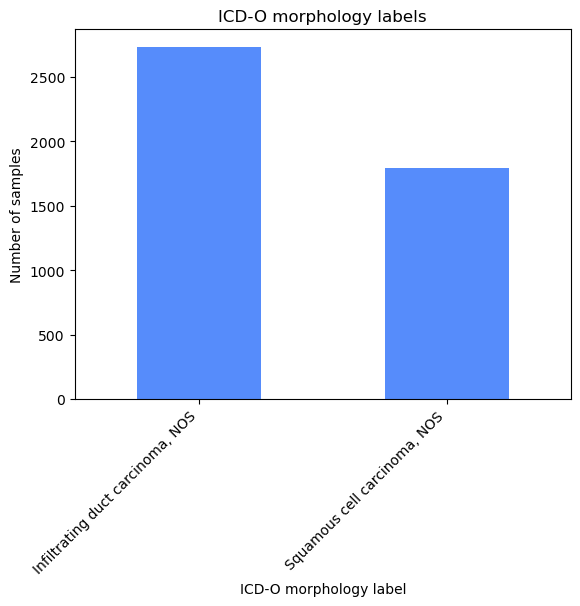

In [32]:
# Plot the top 10 ICD-O morphology labels.

combined_sampletable_df["icdo_morphology_label"].value_counts().head(2).plot(kind="bar")
plt.title("ICD-O morphology labels")
plt.xlabel("ICD-O morphology label")
plt.ylabel("Number of samples")
plt.xticks(rotation=45, ha="right")
plt.show()

In [33]:
# Count ICD-O topography labels.

combined_sampletable_df["icdo_topography_label"].value_counts().head(20)

icdo_topography_label
Breast, NOS                2736
Lung, NOS                   795
Esophagus, NOS              173
Head, face or neck, NOS     133
Cervix uteri                130
Mouth, NOS                  123
Anus, NOS                   117
Skin, NOS                    72
Vagina, NOS                  58
Oropharynx, NOS              52
Unknown primary site         51
Bladder, NOS                 25
Larynx, NOS                  19
Penis, NOS                   14
Nasal cavity                 14
Hypopharynx, NOS              7
Urethra                       7
Nipple                        1
Prostate gland                1
Name: count, dtype: int64

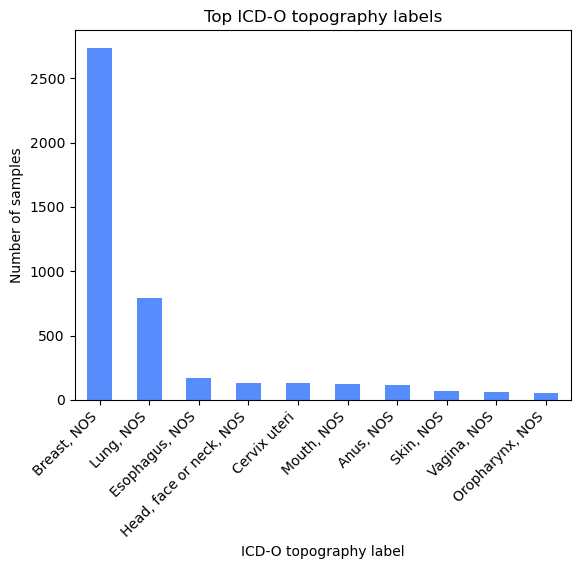

In [34]:
# Plot the top 10 ICD-O topography labels.

combined_sampletable_df["icdo_topography_label"].value_counts().head(10).plot(kind="bar")
plt.title("Top ICD-O topography labels")
plt.xlabel("ICD-O topography label")
plt.ylabel("Number of samples")
plt.xticks(rotation=45, ha="right")
plt.show()

## Export the filtered metadata table

We export the combined metadata table for later use.

In [35]:
# Export the filtered metadata table.

combined_sampletable_df.to_csv("progenetix_combined_sampletable_primary_tumor.csv", index=False)
print("Saved: progenetix_combined_sampletable_primary_tumor.csv")

Saved: progenetix_combined_sampletable_primary_tumor.csv


## Part 2. From raw CNV segments to CNV frequency maps
So far, we have explored how biosamples are annotated in Progenetix.

We now move from sample-level metadata to CNV-level summaries, which
describe the aggregate genomic copy number landscape of a cancer group.

To study CNVs directly, it is useful to distinguish between:

- raw CNV segments
- precomputed CNV frequencies

## Raw CNV segments

In raw CNV segment data:

- each row corresponds to one CNV interval in one biosample
- biosamples can have different numbers of CNV events
- genomic intervals vary in length and position

This means that raw CNV data are not yet arranged as a fixed-size matrix.

## Raw CNV segments versus frequency tables

Sample metadata describes biosamples, but not the CNV intervals themselves.

Raw CNV segment data are interval-based:
- one row per CNV interval
- different samples can have different numbers of intervals

Frequency tables are group-level summaries:
- one row per genomic interval bin
- values summarize gains and losses across many samples

## Precomputed CNV frequencies

Progenetix also provides precomputed CNV frequency maps for diagnostic
groups.

These are group-level summaries across many samples.

Important:
- frequency tables are not sample-level rows
- they summarize CNV patterns across a cancer class
- interval frequencies are stored by default in a 1 Mb binned format

## Official Progenetix frequency plots

Progenetix provides pre-rendered frequency plots for diagnostic groups
through the `collationplots` service.

Examples:
- infiltrating duct carcinoma:
  https://progenetix.org/services/collationplots/?filters=pgx:icdom-85003
- infiltrating duct carcinoma:
  https://progenetix.org/services/collationplots/?filters=pgx:icdom-80703

## Download CNV frequency tables

We now download frequency tables for the same three query groups.

These tables are useful for understanding the aggregate CNV landscape of
each group.

In [36]:
# Define the intervalFrequencies URLs for the same three groups.

frequency_urls = {
    "infiltrating_duct_carcinoma_icdom": "https://progenetix.org/services/intervalFrequencies/?output=pgxseg&filters=pgx:icdom-85003",
    "squamous_cell_carcinoma_icdom": "https://progenetix.org/services/intervalFrequencies/?output=pgxseg&filters=pgx:icdom-80703"
}

In [37]:
# Download the frequency tables.

frequency_tables = {}

for source_query, url in frequency_urls.items():
    print(f"Downloading frequency table for {source_query}")
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    df_freq = pd.read_csv(StringIO(response.text), sep="\t", comment="#")
    df_freq["source_query"] = source_query
    frequency_tables[source_query] = df_freq

In [38]:
# Show the shape of each downloaded frequency table.

for source_query, df_freq in frequency_tables.items():
    print(source_query, df_freq.shape)

infiltrating_duct_carcinoma_icdom (3106, 7)
squamous_cell_carcinoma_icdom (3106, 7)


In [39]:
# Inspect one example frequency table.

frequency_tables["infiltrating_duct_carcinoma_icdom"].head()

,reference_name,start,end,gain_frequency,loss_frequency,no,source_query
pgx:icdom-85003,1,0,400000,4.711,4.099,1,infiltrating_duct_carcinoma_icdom
pgx:icdom-85003,1,400000,1400000,6.482,10.047,2,infiltrating_duct_carcinoma_icdom
pgx:icdom-85003,1,1400000,2400000,5.683,11.589,3,infiltrating_duct_carcinoma_icdom
pgx:icdom-85003,1,2400000,3400000,7.955,22.316,4,infiltrating_duct_carcinoma_icdom
pgx:icdom-85003,1,3400000,4400000,6.316,21.441,5,infiltrating_duct_carcinoma_icdom


In [40]:
# Show the column names of one example frequency table.

frequency_tables["infiltrating_duct_carcinoma_icdom"].columns

Index(['reference_name', 'start', 'end', 'gain_frequency', 'loss_frequency',
       'no', 'source_query'],
      dtype='str')

## Why frequencies are useful

The metadata table tells us which biosamples we selected and how they
are annotated.

The frequency table tells us how often gains and losses occur across
genomic intervals within a diagnostic group.

These are two complementary views:
- metadata is sample-level
- frequency is group-level

## Export frequency tables

We export the individual and combined frequency tables for later use.

In [41]:
# Combine the frequency tables.

combined_frequency_df = pd.concat(
    [frequency_tables[source_query] for source_query in frequency_tables],
    ignore_index=True
)

combined_frequency_df.shape

(6212, 7)

In [42]:
# Export the combined frequency table.

combined_frequency_df.to_csv("progenetix_frequency_combined.csv", index=False)
print("Saved: progenetix_frequency_combined.csv")

Saved: progenetix_frequency_combined.csv


## Summary

At this stage, we have:

- a filtered sample-level metadata table
- group-level CNV frequency tables
- an understanding of how cancer samples are annotated in Progenetix
- an understanding of how aggregate CNV landscapes are summarized

However, raw CNV segments are still not arranged as a fixed-size
feature matrix.

In the next notebook, we will transform raw CNV data into a binary
feature matrix for machine learning classification.

# EXTRA

## Exercise 1. Retrieve 5 biosamples through the Beacon API

Use the Beacon biosamples endpoint to retrieve 5 biosamples for:

One type of cancer, example: 
- `Small cell carcinoma, NOS`
- filter code: `pgx:icdom-80413`

Tasks:
- send the request
- inspect the JSON structure
- extract the results
- convert the results into a pandas DataFrame
- show the first rows of the DataFrame

### Solution: Exercise 1

In [43]:
import requests
import pandas as pd

url = "https://progenetix.org/beacon/biosamples"
params = {
    "filters": "pgx:icdom-80413",
    "limit": 5
}

response = requests.get(url, params=params)
data = response.json()
results = data["response"]["resultSets"][0]["results"]

df_api = pd.json_normalize(results)
df_api.head()

,cohorts,collectionMoment,collectionMomentDays,externalReferences,id,individualId,name,notes,updated,biosampleStatus.id,...,individualInfo.sex.id,individualInfo.sex.label,sampleOriginDetail.id,sampleOriginDetail.label,sampleOriginType.id,sampleOriginType.label,tumorGrade.id,tumorGrade.label,pathologicalStage.id,pathologicalStage.label
0,"[{'id': 'pgx:cohort-GENIE-MSK', 'label': 'GENI...",P53Y,19357,[],pgxbs-m84cy0zg,pgxind-m84cxs2u,GENIE-MSK-P-0016136-T01-IM6,Small Cell Lung Cancer,2025-06-12T13:36:52.412624,EFO:0010942,...,NCIT:C16576,female,UBERON:0002048,lung,OBI:0001479,specimen from organism,NaN,NaN,NaN,NaN
1,"[{'id': 'pgx:cohort-GENIE-MSK', 'label': 'GENI...",P68Y,24836,[],pgxbs-m84d5dxo,pgxind-m84d300n,GENIE-MSK-P-0049106-T03-IM6,Small Bowel Well-Differentiated Neuroendocrine...,2025-06-12T13:40:25.358720,EFO:0010942,...,NCIT:C20197,male,UBERON:0018707,bladder organ,OBI:0001479,specimen from organism,NCIT:C14161,Low Grade,NaN,NaN
2,"[{'id': 'pgx:cohort-GENIE-MSK', 'label': 'GENI...",P89Y1M1D,32537,[],pgxbs-m84d1kce,pgxind-m84d0gnz,GENIE-MSK-P-0035131-T01-IM6,Small Cell Lung Cancer [metastasis],2025-06-12T13:38:38.164204,EFO:0010941,...,NCIT:C20197,male,UBERON:0002048,lung,OBI:0001479,specimen from organism,NaN,NaN,NaN,NaN
3,"[{'id': 'pgx:cohort-GENIE-MSK', 'label': 'GENI...",P71Y,25932,[],pgxbs-m84d5xn9,pgxind-m84d3eb3,GENIE-MSK-P-0052980-T01-IM6,Small Cell Bladder Cancer,2025-06-12T13:40:40.130747,EFO:0010942,...,NCIT:C20197,male,UBERON:0018707,bladder organ,OBI:0001479,specimen from organism,NaN,NaN,NaN,NaN
4,"[{'id': 'cbioportal:lung_pdx_msk_2021', 'label...",P69Y,25201,"[{'description': 'Zehir A, Benayed R et al. (2...",pgxbs-kftvkwlq,pgxind-kftx73ih,P-0000132-T01-IM3,"Small Cell Lung Cancer [MSS,Lymph Node metasta...",2025-07-11T16:55:26.929485,EFO:0009656,...,NCIT:C16576,female,UBERON:0002048,lung,OBI:0001479,specimen from organism,NaN,NaN,NCIT:C92207,Stage Unknown


## Exercise 2. Download the same cancer type through the sampletable service

Now download `Small cell carcinoma, NOS` (Or the cancer type you choose) again, but this time using the
`sampletable` service.

Tasks:
- download the table
- inspect the shape
- compare it with the API-based DataFrame from Exercise 1
- explain one difference between the two download methods

### Solution: Exercise 2

In [44]:
from io import StringIO

sampletable_url = "https://progenetix.org/services/sampletable/?filters=pgx:icdom-80413&limit=0"
response = requests.get(sampletable_url)
df_sampletable = pd.read_csv(StringIO(response.text), sep="\t")

print("Shape of sampletable DataFrame:", df_sampletable.shape)
print("Shape of API DataFrame (Exercise 1):", df_api.shape)

df_sampletable.head()
df_api.head()

# One difference is that the API returns nested JSON data which needs flattening (json_normalize),
# whereas the sampletable service returns a pre-formatted tab-separated table that is easier to read directly into pandas.

Shape of sampletable DataFrame: (1529, 42)
Shape of API DataFrame (Exercise 1): (5, 39)


,cohorts,collectionMoment,collectionMomentDays,externalReferences,id,individualId,name,notes,updated,biosampleStatus.id,...,individualInfo.sex.id,individualInfo.sex.label,sampleOriginDetail.id,sampleOriginDetail.label,sampleOriginType.id,sampleOriginType.label,tumorGrade.id,tumorGrade.label,pathologicalStage.id,pathologicalStage.label
0,"[{'id': 'pgx:cohort-GENIE-MSK', 'label': 'GENI...",P53Y,19357,[],pgxbs-m84cy0zg,pgxind-m84cxs2u,GENIE-MSK-P-0016136-T01-IM6,Small Cell Lung Cancer,2025-06-12T13:36:52.412624,EFO:0010942,...,NCIT:C16576,female,UBERON:0002048,lung,OBI:0001479,specimen from organism,NaN,NaN,NaN,NaN
1,"[{'id': 'pgx:cohort-GENIE-MSK', 'label': 'GENI...",P68Y,24836,[],pgxbs-m84d5dxo,pgxind-m84d300n,GENIE-MSK-P-0049106-T03-IM6,Small Bowel Well-Differentiated Neuroendocrine...,2025-06-12T13:40:25.358720,EFO:0010942,...,NCIT:C20197,male,UBERON:0018707,bladder organ,OBI:0001479,specimen from organism,NCIT:C14161,Low Grade,NaN,NaN
2,"[{'id': 'pgx:cohort-GENIE-MSK', 'label': 'GENI...",P89Y1M1D,32537,[],pgxbs-m84d1kce,pgxind-m84d0gnz,GENIE-MSK-P-0035131-T01-IM6,Small Cell Lung Cancer [metastasis],2025-06-12T13:38:38.164204,EFO:0010941,...,NCIT:C20197,male,UBERON:0002048,lung,OBI:0001479,specimen from organism,NaN,NaN,NaN,NaN
3,"[{'id': 'pgx:cohort-GENIE-MSK', 'label': 'GENI...",P71Y,25932,[],pgxbs-m84d5xn9,pgxind-m84d3eb3,GENIE-MSK-P-0052980-T01-IM6,Small Cell Bladder Cancer,2025-06-12T13:40:40.130747,EFO:0010942,...,NCIT:C20197,male,UBERON:0018707,bladder organ,OBI:0001479,specimen from organism,NaN,NaN,NaN,NaN
4,"[{'id': 'cbioportal:lung_pdx_msk_2021', 'label...",P69Y,25201,"[{'description': 'Zehir A, Benayed R et al. (2...",pgxbs-kftvkwlq,pgxind-kftx73ih,P-0000132-T01-IM3,"Small Cell Lung Cancer [MSS,Lymph Node metasta...",2025-07-11T16:55:26.929485,EFO:0009656,...,NCIT:C16576,female,UBERON:0002048,lung,OBI:0001479,specimen from organism,NaN,NaN,NCIT:C92207,Stage Unknown


## Exercise 3. Explore diagnostic labels

Using the downloaded sample table for `Small cell carcinoma, NOS` (Or the cancer type you choose) :

- count the values of `histological_diagnosis_label`
- count the values of `icdo_morphology_label`
- count the values of `icdo_topography_label`
- explain in 1–2 sentences what each label field describes

### Solution: Exercise 3

In [45]:
print("Histological Diagnosis Label counts:")
print(df_sampletable["histological_diagnosis_label"].value_counts())
print("\nICD-O Morphology Label counts:")
print(df_sampletable["icdo_morphology_label"].value_counts())
print("\nICD-O Topography Label counts:")
print(df_sampletable["icdo_topography_label"].value_counts())

# histological_diagnosis_label: The general clinical name of the cancer (e.g., Small cell lung cancer).
# icdo_morphology_label: The specific microscopic appearance or cell type of the tumor (ICD-O 3 code description).
# icdo_topography_label: The anatomical site or organ where the tumor originated.

Histological Diagnosis Label counts:
histological_diagnosis_label
Lung Small Cell Carcinoma                          1193
Bladder Small Cell Neuroendocrine Carcinoma         176
Small Cell Neuroendocrine Carcinoma                  76
Prostate Small Cell Neuroendocrine Carcinoma         43
Ovarian Small Cell Carcinoma                         19
Cervical Small Cell Neuroendocrine Carcinoma         15
Gastric Small Cell Neuroendocrine Carcinoma           6
Gallbladder Small Cell Neuroendocrine Carcinoma       1
Name: count, dtype: int64

ICD-O Morphology Label counts:
icdo_morphology_label
Small cell carcinoma, NOS    1529
Name: count, dtype: int64

ICD-O Topography Label counts:
icdo_topography_label
Lung, NOS               1193
Bladder, NOS             174
Unknown primary site      75
Prostate gland            43
Ovary                     19
Cervix uteri              15
Stomach, NOS               6
Gallbladder                3
Labium majus               1
Name: count, dtype: int64


## Exercise 4. Download and interpret CNV frequency data

Now download the CNV frequency table for:

Example:
- `Small cell carcinoma, NOS`
- filter code: `pgx:icdom-80413`

Tasks:
- download the frequency table
- inspect its shape
- inspect its columns
- Explain why the frequency table has a different shape from the sample table.
    - what one row represents in the sample table
    - what one row represents in the frequency table
    - why these two tables cannot be merged row by row

### Solution: Exercise 4

In [46]:
freq_url = "https://progenetix.org/services/intervalFrequencies/?output=pgxseg&filters=pgx:icdom-80413"
response = requests.get(freq_url)
df_freq = pd.read_csv(StringIO(response.text), sep="\t", comment="#")

print("Shape of frequency table:", df_freq.shape)
print("Columns:", df_freq.columns.tolist())

# A row in the sample table represents one biosample (metadata).
# A row in the frequency table represents one genomic interval (bin), here / usually 1Mb wide.
# They cannot be merged row-by-row because they describe different entities at different levels:
#   one is sample-centric metadata, the other is genome-centric aggregate statistics for a group.

Shape of frequency table: (3106, 6)
Columns: ['reference_name', 'start', 'end', 'gain_frequency', 'loss_frequency', 'no']
